# Notebook 07 — Diagnostico del modelo (residuales, sesgo y contenido de NASA)

Este notebook produce los diagnosticos complementarios de la Actividad 3 a partir de los **modelos ya entrenados** en el Notebook 06 (`MODO = 'completo'`). **No reentrena nada**: carga los checkpoints guardados en `modelos/` y regenera las predicciones por inferencia, de modo que puede ejecutarse en una sesion nueva de Colab sin repetir el entrenamiento.

**Como ejecutarlo:** correr todas las celdas de arriba hacia abajo. Las celdas de preparacion (montaje, carga de artefactos, definiciones) son las mismas del Notebook 06 y solo definen funciones y cargan datos; el entrenamiento no se ejecuta.

**Contenido (los cuatro puntos del diagnostico):**
1. Diagnostico de residuales del modelo: error medio (sesgo), sesgo por nivel de irradiancia y por hora del dia, autocorrelacion de residuales (ACF y Ljung-Box) y residual frente a observado.
2. Figura de prediccion frente a observacion con **ventanas representativas** (corrige la version anterior, que elegia la ventana mas volatil).
3. Diagnostico del contenido de alta frecuencia de las variables de NASA POWER frente a la RS de la estacion.
4. Tabla de metricas ampliada con el **error medio (ME)** como base del analisis de sesgo.

**Encuadre metodologico:** estos analisis son un *diagnostico del modelo*, no una validacion de supuestos estadisticos. El Informer no descansa sobre supuestos de normalidad, homocedasticidad o ausencia de multicolinealidad; los residuales se examinan para caracterizar donde y como se equivoca el modelo, no para validar su legitimidad.

In [1]:
# 1. Configuracion del entorno
!pip install torch numpy pandas matplotlib scikit-learn statsmodels --quiet

import os, sys, gc, time, pickle, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torch.amp import autocast, GradScaler

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE_TYPE = 'cuda' if torch.cuda.is_available() else 'cpu'
USE_AMP     = torch.cuda.is_available()

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

# Debe coincidir con el MODO usado al entrenar en el Notebook 06.
# Los checkpoints se llaman informer_..._completo.pt, por lo que aqui va 'completo'.
MODO = 'completo'

print('PyTorch :', torch.__version__)
print('Device  :', DEVICE)
print('MODO    :', MODO)

PyTorch : 2.11.0+cu128
Device  : cuda
MODO    : completo


In [2]:
# 2. Montaje de Google Drive y resolucion de rutas
from google.colab import drive
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print('Drive ya montado.')

res = subprocess.run(
    ['find', '/content/drive/MyDrive', '-name', 'config_fe.pkl'],
    capture_output=True, text=True, timeout=240
)
rutas = [r for r in res.stdout.strip().split('\n') if r]
if not rutas:
    raise FileNotFoundError('No se encontro config_fe.pkl. Ejecute primero el Notebook 04.')

RUTA_ARRAYS = os.path.dirname(
    next((r for r in rutas if any(k in r for k in ['Maestr', 'Codigos', 'Trabajo', 'arrays'])), rutas[0])
)
RUTA_DATOS   = os.path.dirname(RUTA_ARRAYS)
RUTA_BASE    = os.path.dirname(RUTA_DATOS)
RUTA_MODELOS = os.path.join(RUTA_BASE, 'modelos')
RUTA_FIGS    = os.path.join(RUTA_BASE, 'figuras')
RUTA_RES     = os.path.join(RUTA_BASE, 'resultados')
for d in (RUTA_MODELOS, RUTA_FIGS, RUTA_RES):
    os.makedirs(d, exist_ok=True)

print('RUTA_ARRAYS  :', RUTA_ARRAYS)
print('RUTA_MODELOS :', RUTA_MODELOS)
print('RUTA_RES     :', RUTA_RES)

Mounted at /content/drive
RUTA_ARRAYS  : /content/drive/MyDrive/Maestria Ciencia de Datos Segundo Semestre/Proyecto Aplicado ll/Codigos Trabajo de Grado/datos/arrays
RUTA_MODELOS : /content/drive/MyDrive/Maestria Ciencia de Datos Segundo Semestre/Proyecto Aplicado ll/Codigos Trabajo de Grado/modelos
RUTA_RES     : /content/drive/MyDrive/Maestria Ciencia de Datos Segundo Semestre/Proyecto Aplicado ll/Codigos Trabajo de Grado/resultados


In [3]:
# 3. Arquitectura de referencia: Informer oficial (zhouhaoyi/Informer2020)
REPO_INFORMER = '/content/Informer2020'
if not os.path.exists(REPO_INFORMER):
    subprocess.run(['git', 'clone', '--depth', '1',
                    'https://github.com/zhouhaoyi/Informer2020.git',
                    REPO_INFORMER], check=True)
if REPO_INFORMER not in sys.path:
    sys.path.append(REPO_INFORMER)

from models.model import Informer
print('Arquitectura Informer importada correctamente.')

Arquitectura Informer importada correctamente.


In [4]:
# 4. Carga de artefactos del Notebook 04 y de la mejor configuracion (Notebook 05)
data_norm   = np.load(os.path.join(RUTA_ARRAYS, 'data_norm.npy'))
marcas_temp = np.load(os.path.join(RUTA_ARRAYS, 'marcas_temp.npy'))
with open(os.path.join(RUTA_ARRAYS, 'config_fe.pkl'), 'rb') as f:
    config = pickle.load(f)
with open(os.path.join(RUTA_ARRAYS, 'scaler_rs.pkl'), 'rb') as f:
    scaler_rs = pickle.load(f)

VARS_ENTRADA  = list(config['vars_entrada'])
VAR_OBJETIVO  = config['var_objetivo']
SEQ_LEN       = config['seq_len']
LABEL_LEN     = config['label_len']
PRED_LENS     = config['pred_lens']
IDX_TRAIN_END = config['idx_train_end']
IDX_VAL_END   = config['idx_val_end']
N_TOTAL       = config['n_total']
RS_MIN   = float(scaler_rs.data_min_[0])
RS_RANGE = float(scaler_rs.data_range_[0])

ruta_hp = os.path.join(RUTA_RES, 'hp_best.pkl')
if not os.path.exists(ruta_hp):
    raise FileNotFoundError('No se encontro hp_best.pkl. Ejecute primero el Notebook 05 (idealmente en MODO completo).')
with open(ruta_hp, 'rb') as f:
    HP_BEST = pickle.load(f)

print('data_norm :', data_norm.shape, '| RS_range:', round(RS_RANGE, 1), 'W/m2')
print('Horizontes:', PRED_LENS)
print('Hiperparametros seleccionados (hp_best.pkl):')
for k, v in HP_BEST.items():
    print(f'  {k:<10}: {v}')

data_norm : (1330560, 18) | RS_range: 1524.0 W/m2
Horizontes: {'1h': 12, '3h': 36, '6h': 72}
Hiperparametros seleccionados (hp_best.pkl):
  d_model   : 256
  n_heads   : 4
  e_layers  : 3
  d_layers  : 1
  d_ff      : 128
  dropout   : 0.05
  factor    : 5
  lr        : 0.0001


## Preparacion (identica al Notebook 06)

Las celdas siguientes son las mismas del Notebook 06: montan Drive, clonan el Informer, cargan los artefactos y `hp_best.pkl`, y definen las variantes, el `InformerDataset`, los constructores y las funciones de evaluacion. **Ninguna entrena.** Solo dejan en memoria lo necesario para evaluar los modelos ya guardados.

In [5]:
# 6. Variantes y clase InformerDataset
GRUPOS_VARIABLES = {
    'V1_autorregresivo': ['RS', 'sin_hora', 'cos_hora',
                          'sin_dia_anio', 'cos_dia_anio', 'sin_mes', 'cos_mes'],
    'V2_meteo_nasa': ['RS', 'sin_hora', 'cos_hora',
                      'sin_dia_anio', 'cos_dia_anio', 'sin_mes', 'cos_mes',
                      'T2M', 'RH2M', 'PRECTOTCORR',
                      'WS10M', 'WD10M_u', 'WD10M_v', 'PS', 'SZA'],
    'V3_completo': list(VARS_ENTRADA),
}

def columnas_variante(nombre_variante):
    return [VARS_ENTRADA.index(v) for v in GRUPOS_VARIABLES[nombre_variante]]

class InformerDataset(Dataset):
    def __init__(self, data, marcas, idx_inicio, idx_fin,
                 seq_len, label_len, pred_len, idx_objetivo):
        self.data, self.marcas = data, marcas
        self.seq_len, self.label_len, self.pred_len = seq_len, label_len, pred_len
        self.idx_objetivo = idx_objetivo
        self._inicio = max(idx_inicio, seq_len)
        self._fin    = min(idx_fin, len(data) - pred_len)
        self._len    = max(0, self._fin - self._inicio)

    def __len__(self):
        return self._len

    def __getitem__(self, i):
        t = self._inicio + i
        enc_input = self.data[t - self.seq_len:t, :]
        enc_mark  = self.marcas[t - self.seq_len:t, :]
        dec_input = self.data[t - self.label_len:t + self.pred_len, :].copy()
        dec_mark  = self.marcas[t - self.label_len:t + self.pred_len, :]
        dec_input[self.label_len:, self.idx_objetivo] = 0.0
        target = self.data[t:t + self.pred_len, self.idx_objetivo]
        return (torch.from_numpy(enc_input), torch.from_numpy(enc_mark),
                torch.from_numpy(dec_input), torch.from_numpy(dec_mark),
                torch.from_numpy(target))

print('Variantes y InformerDataset definidos.')

Variantes y InformerDataset definidos.


In [6]:
# 7. Constructores de DataLoaders y del modelo
def build_loaders(nombre_variante, nombre_horizonte,
                  stride_train, stride_eval, batch_size, num_workers=2):
    cols     = columnas_variante(nombre_variante)
    data_sub = np.ascontiguousarray(data_norm[:, cols])
    pred_len = PRED_LENS[nombre_horizonte]
    enc_in   = data_sub.shape[1]
    splits = [('train', 0, IDX_TRAIN_END, stride_train),
              ('val',   IDX_TRAIN_END, IDX_VAL_END, stride_eval),
              ('test',  IDX_VAL_END, N_TOTAL, stride_eval)]
    loaders, tam = {}, {}
    for split, i_ini, i_fin, stride in splits:
        ds_full = InformerDataset(data_sub, marcas_temp, i_ini, i_fin,
                                  SEQ_LEN, LABEL_LEN, pred_len, idx_objetivo=0)
        ds = Subset(ds_full, list(range(0, len(ds_full), stride)))
        loaders[split] = DataLoader(ds, batch_size=batch_size,
                                    shuffle=(split == 'train'),
                                    num_workers=num_workers, pin_memory=USE_AMP,
                                    drop_last=(split == 'train'))
        tam[split] = len(ds)
    return loaders, enc_in, pred_len, tam

def build_informer(enc_in, pred_len, hp):
    return Informer(
        enc_in=enc_in, dec_in=enc_in, c_out=1,
        seq_len=SEQ_LEN, label_len=LABEL_LEN, out_len=pred_len,
        factor=hp['factor'], d_model=hp['d_model'], n_heads=hp['n_heads'],
        e_layers=hp['e_layers'], d_layers=hp['d_layers'], d_ff=hp['d_ff'],
        dropout=hp['dropout'], attn='prob', embed='timeF', freq='h',
        activation='gelu', output_attention=False, distil=True, mix=True,
        device=DEVICE
    ).to(DEVICE)

print('Constructores definidos.')

Constructores definidos.


In [7]:
# 8. Motor de entrenamiento (identico al del Notebook 05)
def _mover(batch):
    enc, enc_m, dec, dec_m, tgt = batch
    return (enc.to(DEVICE), enc_m.to(DEVICE), dec.to(DEVICE),
            dec_m.to(DEVICE), tgt.to(DEVICE))

@torch.no_grad()
def evaluate_loss(model, loader, criterion):
    model.eval()
    total, n = 0.0, 0
    for batch in loader:
        enc, enc_m, dec, dec_m, tgt = _mover(batch)
        with autocast(DEVICE_TYPE, enabled=USE_AMP):
            out = model(enc, enc_m, dec, dec_m).squeeze(-1)
            loss = criterion(out, tgt)
        total += loss.item() * tgt.size(0); n += tgt.size(0)
    return total / max(n, 1)

def train_model(model, loaders, max_epochs, lr, weight_decay=1e-4,
                patience=4, clip=1.0, ruta_ckpt=None, verbose=True):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    scaler = GradScaler(DEVICE_TYPE, enabled=USE_AMP)
    historia = {'train_loss': [], 'val_loss': [], 'lr': []}
    best_val, sin_mejora = float('inf'), 0
    for epoch in range(1, max_epochs + 1):
        model.train(); t0, suma, n = time.time(), 0.0, 0
        for batch in loaders['train']:
            enc, enc_m, dec, dec_m, tgt = _mover(batch)
            optimizer.zero_grad(set_to_none=True)
            with autocast(DEVICE_TYPE, enabled=USE_AMP):
                out = model(enc, enc_m, dec, dec_m).squeeze(-1)
                loss = criterion(out, tgt)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            scaler.step(optimizer); scaler.update()
            suma += loss.item() * tgt.size(0); n += tgt.size(0)
        train_loss = suma / max(n, 1)
        val_loss = evaluate_loss(model, loaders['val'], criterion)
        scheduler.step(val_loss)
        historia['train_loss'].append(train_loss)
        historia['val_loss'].append(val_loss)
        historia['lr'].append(optimizer.param_groups[0]['lr'])
        if verbose:
            print(f'  Epoca {epoch:>2}/{max_epochs} | train {train_loss:.5e} | val {val_loss:.5e} | {time.time()-t0:.1f}s')
        if val_loss < best_val - 1e-7:
            best_val, sin_mejora = val_loss, 0
            if ruta_ckpt is not None:
                torch.save(model.state_dict(), ruta_ckpt)
        else:
            sin_mejora += 1
            if sin_mejora >= patience:
                if verbose:
                    print(f'  Parada temprana en epoca {epoch}.')
                break
    return best_val, historia

print('Motor de entrenamiento definido.')

Motor de entrenamiento definido.


In [8]:
# 10. Desnormalizacion, metricas y recoleccion de predicciones
def desnormalizar_rs(x_norm):
    return x_norm * RS_RANGE + RS_MIN   # [0,1] -> W/m2

def metricas(y_true, y_pred, umbral_diurno=10.0):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.clip(np.asarray(y_pred).ravel(), 0.0, None)  # irradiancia no negativa
    err = y_pred - y_true
    mae  = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err ** 2)))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = float(1 - np.sum(err ** 2) / ss_tot) if ss_tot > 0 else float('nan')
    m = y_true > umbral_diurno   # mascara diurna
    if m.sum() > 0:
        ed = y_pred[m] - y_true[m]
        mae_d  = float(np.mean(np.abs(ed)))
        rmse_d = float(np.sqrt(np.mean(ed ** 2)))
        sst_d  = float(np.sum((y_true[m] - y_true[m].mean()) ** 2))
        r2_d   = float(1 - np.sum(ed ** 2) / sst_d) if sst_d > 0 else float('nan')
        smape  = float(100 * np.mean(2 * np.abs(ed) / (np.abs(y_true[m]) + np.abs(y_pred[m]) + 1e-8)))
    else:
        mae_d = rmse_d = r2_d = smape = float('nan')
    return dict(MAE=mae, RMSE=rmse, R2=r2,
                MAE_diurno=mae_d, RMSE_diurno=rmse_d, R2_diurno=r2_d, sMAPE_diurno=smape)

@torch.no_grad()
def predecir(model, loader):
    model.eval()
    preds, trues, pers = [], [], []
    for batch in loader:
        enc, enc_m, dec, dec_m, tgt = _mover(batch)
        with autocast(DEVICE_TYPE, enabled=USE_AMP):
            out = model(enc, enc_m, dec, dec_m).squeeze(-1)
        preds.append(out.float().cpu().numpy())
        trues.append(tgt.float().cpu().numpy())
        ultimo = enc[:, -1, 0].float().cpu().numpy()[:, None]   # persistencia: ultimo RS observado
        pers.append(np.repeat(ultimo, tgt.shape[1], axis=1))
    return np.concatenate(preds), np.concatenate(trues), np.concatenate(pers)

print('Funciones de evaluacion definidas.')

Funciones de evaluacion definidas.


## Bloque de diagnostico (puntos 1 a 4)

A partir de aqui comienza el contenido nuevo. Cada celda carga los checkpoints, ejecuta inferencia sobre el conjunto de prueba y produce una tabla o figura para la seccion de Resultados. El modelo a diagnosticar en el analisis de residuales es configurable (`VAR_DIAG`, `H_DIAG`).

In [9]:
# 12. Configuracion del diagnostico y funciones auxiliares
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

# Modelo a diagnosticar en el analisis de residuales (puede cambiarse).
VAR_DIAG = 'V1_autorregresivo'   # variante para los residuales
H_DIAG   = '1h'                  # horizonte para los residuales
N_SEG    = 20000                 # longitud del tramo contiguo de prueba para la ACF (pasos de 5 min)

def detectar_columna_hora(marcas):
    # Identifica la columna de la hora del dia sin depender de su posicion:
    # es la que alcanza el valor 0 y tiene cerca de 24 valores distintos.
    mejor, mejor_n = None, -1
    for c in range(marcas.shape[1]):
        col = marcas[:, c]
        n_un = len(np.unique(np.round(col, 4)))
        if float(col.min()) < 0.01 and 20 <= n_un <= 28 and n_un > mejor_n:
            mejor, mejor_n = c, n_un
    return mejor

COL_HORA = detectar_columna_hora(marcas_temp)
HORA = np.round(marcas_temp[:, COL_HORA] * 23).astype(int) if COL_HORA is not None else None
print('Columna de hora detectada:', COL_HORA,
      '| rango de horas:', (HORA.min(), HORA.max()) if HORA is not None else 'no detectada')

@torch.no_grad()
def predecir_contiguo(variante, horizonte, n_seg):
    # Predicciones ordenadas sobre un tramo contiguo del conjunto de prueba (stride=1),
    # para construir una serie de residuales sin huecos (necesaria para la ACF).
    cols = columnas_variante(variante)
    data_sub = np.ascontiguousarray(data_norm[:, cols])
    pred_len = PRED_LENS[horizonte]
    i_fin = min(IDX_VAL_END + n_seg, N_TOTAL)
    ds = InformerDataset(data_sub, marcas_temp, IDX_VAL_END, i_fin,
                         SEQ_LEN, LABEL_LEN, pred_len, idx_objetivo=0)
    loader = DataLoader(ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=USE_AMP)
    ckpt = os.path.join(RUTA_MODELOS, f'informer_{variante}__{horizonte}_{MODO}.pt')
    modelo = build_informer(len(cols), pred_len, HP_BEST)
    modelo.load_state_dict(torch.load(ckpt, map_location=DEVICE)); modelo.eval()
    preds, trues = [], []
    for batch in loader:
        enc, enc_m, dec, dec_m, tgt = _mover(batch)
        with autocast(DEVICE_TYPE, enabled=USE_AMP):
            out = modelo(enc, enc_m, dec, dec_m).squeeze(-1)
        preds.append(out.float().cpu().numpy()); trues.append(tgt.float().cpu().numpy())
    del modelo; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    p, t = np.concatenate(preds), np.concatenate(trues)
    t_idx = np.arange(IDX_VAL_END, IDX_VAL_END + len(p))   # indice de tiempo del primer paso
    return p, t, t_idx

print('Configuracion y funciones auxiliares listas.')

Columna de hora detectada: 3 | rango de horas: (np.int64(0), np.int64(23))
Configuracion y funciones auxiliares listas.


In [10]:
# 13. PUNTO 4: tabla de metricas ampliada con el error medio (ME / sesgo)
def metricas_con_me(y_true, y_pred, umbral=10.0):
    yt = np.asarray(y_true).ravel()
    yp = np.clip(np.asarray(y_pred).ravel(), 0.0, None)
    base = metricas(yt, yp, umbral)                 # reutiliza la funcion de la preparacion
    base['ME'] = float(np.mean(yp - yt))            # sesgo global: + sobreestima, - subestima
    m = yt > umbral
    base['ME_diurno'] = float(np.mean(yp[m] - yt[m])) if m.sum() > 0 else float('nan')
    return base

filas = []
for variante in GRUPOS_VARIABLES:
    for horizonte in PRED_LENS:
        ckpt = os.path.join(RUTA_MODELOS, f'informer_{variante}__{horizonte}_{MODO}.pt')
        if not os.path.exists(ckpt):
            print(f'[{variante}__{horizonte}] sin checkpoint, se omite.'); continue
        loaders, enc_in, pred_len, _ = build_loaders(variante, horizonte, 18, 18, 64)
        modelo = build_informer(enc_in, pred_len, HP_BEST)
        modelo.load_state_dict(torch.load(ckpt, map_location=DEVICE))
        p, t, per = predecir(modelo, loaders['test'])
        p_w, t_w, per_w = desnormalizar_rs(p), desnormalizar_rs(t), desnormalizar_rs(per)
        m_mod = metricas_con_me(t_w, p_w)
        m_per = metricas(t_w, per_w)
        skill = float(1 - m_mod['RMSE'] / m_per['RMSE']) if m_per['RMSE'] > 0 else float('nan')
        filas.append(dict(variante=variante, horizonte=horizonte, **m_mod,
                          RMSE_persistencia=m_per['RMSE'], skill_RMSE=skill))
        del modelo, loaders; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

orden = ['variante','horizonte','MAE','RMSE','R2','ME',
         'MAE_diurno','RMSE_diurno','R2_diurno','ME_diurno','sMAPE_diurno',
         'RMSE_persistencia','skill_RMSE']
df_met = pd.DataFrame(filas)
df_met = df_met[[c for c in orden if c in df_met.columns]]
df_met.to_csv(os.path.join(RUTA_RES, 'metricas_variantes.csv'), index=False)
print(df_met.round(3).to_string(index=False))
print('Tabla actualizada con ME: resultados/metricas_variantes.csv')

         variante horizonte    MAE    RMSE    R2     ME  MAE_diurno  RMSE_diurno  R2_diurno  ME_diurno  sMAPE_diurno  RMSE_persistencia  skill_RMSE
V1_autorregresivo        1h 61.451 125.421 0.726  3.254     126.463      185.593      0.529    -14.139        42.269            147.629       0.150
V1_autorregresivo        3h 69.555 136.971 0.674  4.902     138.363      199.465      0.462    -16.424        43.864            196.620       0.303
V1_autorregresivo        6h 76.582 146.547 0.627 10.010     146.210      207.203      0.419    -13.149        47.540            257.346       0.431
    V2_meteo_nasa        1h 62.599 123.106 0.736  4.841     123.723      184.354      0.536    -16.004        39.131            147.629       0.166
    V2_meteo_nasa        3h 76.078 143.219 0.644  7.375     141.991      204.296      0.435    -22.510        46.518            196.620       0.272
    V2_meteo_nasa        6h 76.819 152.076 0.598  1.579     146.862      214.172      0.380    -33.215        47

Modelo diagnosticado: V1_autorregresivo | horizonte 1h | n = 20000
ME (sesgo global) :    13.97 W/m2   (+ sobreestima / - subestima)
MAE               :    50.75 W/m2
RMSE              :   100.17 W/m2

Prueba de Ljung-Box (H0: ausencia de autocorrelacion en los residuales):
       lb_stat  lb_pvalue
12  44981.8667        0.0
36  80810.8788        0.0
72  92972.9977        0.0


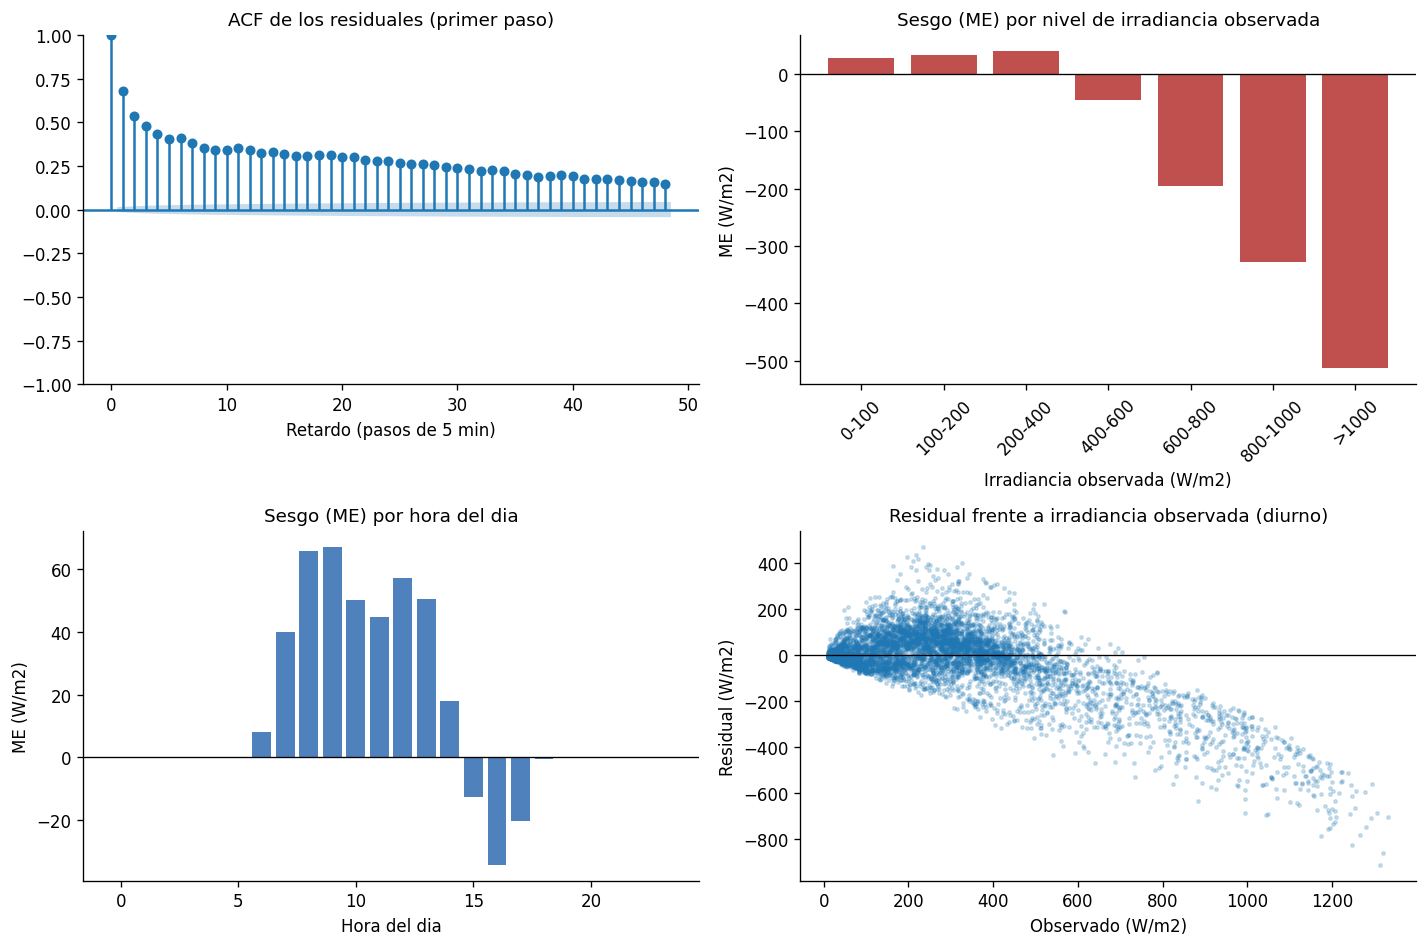

Figura guardada: figuras/diagnostico_residuales_V1_autorregresivo_1h.png


In [11]:
# 14. PUNTO 1: diagnostico de residuales (diagnostico de modelo, no validacion de supuestos)
p, t, t_idx = predecir_contiguo(VAR_DIAG, H_DIAG, N_SEG)
p_w = np.clip(desnormalizar_rs(p), 0, None)
t_w = desnormalizar_rs(t)
res  = p_w[:, 0] - t_w[:, 0]      # residual del primer paso (serie contigua a 5 min)
obs0 = t_w[:, 0]
hora0 = HORA[t_idx] if HORA is not None else None

print(f'Modelo diagnosticado: {VAR_DIAG} | horizonte {H_DIAG} | n = {len(res)}')
print(f'ME (sesgo global) : {res.mean():8.2f} W/m2   (+ sobreestima / - subestima)')
print(f'MAE               : {np.mean(np.abs(res)):8.2f} W/m2')
print(f'RMSE              : {np.sqrt(np.mean(res**2)):8.2f} W/m2')

lb = acorr_ljungbox(res, lags=[12, 36, 72], return_df=True)
print('\nPrueba de Ljung-Box (H0: ausencia de autocorrelacion en los residuales):')
print(lb.round(4).to_string())

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
plot_acf(res, lags=48, ax=axs[0, 0], alpha=0.05)
axs[0, 0].set_title('ACF de los residuales (primer paso)')
axs[0, 0].set_xlabel('Retardo (pasos de 5 min)')

bins = np.array([0, 100, 200, 400, 600, 800, 1000, 1600])
etiq = ['0-100', '100-200', '200-400', '400-600', '600-800', '800-1000', '>1000']
ib = np.digitize(obs0, bins) - 1
me_bin = [res[ib == k].mean() if (ib == k).sum() > 0 else np.nan for k in range(len(etiq))]
axs[0, 1].bar(etiq, me_bin, color='#c0504d'); axs[0, 1].axhline(0, color='k', lw=0.8)
axs[0, 1].set_title('Sesgo (ME) por nivel de irradiancia observada')
axs[0, 1].set_xlabel('Irradiancia observada (W/m2)'); axs[0, 1].set_ylabel('ME (W/m2)')
axs[0, 1].tick_params(axis='x', rotation=45)

if hora0 is not None:
    horas = np.arange(24)
    me_h = [res[hora0 == h].mean() if (hora0 == h).sum() > 0 else np.nan for h in horas]
    axs[1, 0].bar(horas, me_h, color='#4f81bd'); axs[1, 0].axhline(0, color='k', lw=0.8)
    axs[1, 0].set_title('Sesgo (ME) por hora del dia')
    axs[1, 0].set_xlabel('Hora del dia'); axs[1, 0].set_ylabel('ME (W/m2)')
else:
    axs[1, 0].text(0.5, 0.5, 'Hora no detectada', ha='center', va='center', transform=axs[1, 0].transAxes)

md = obs0 > 10
axs[1, 1].scatter(obs0[md], res[md], s=4, alpha=0.2); axs[1, 1].axhline(0, color='k', lw=0.8)
axs[1, 1].set_title('Residual frente a irradiancia observada (diurno)')
axs[1, 1].set_xlabel('Observado (W/m2)'); axs[1, 1].set_ylabel('Residual (W/m2)')

plt.tight_layout()
fig.savefig(os.path.join(RUTA_FIGS, f'diagnostico_residuales_{VAR_DIAG}_{H_DIAG}.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: figuras/diagnostico_residuales_%s_%s.png' % (VAR_DIAG, H_DIAG))

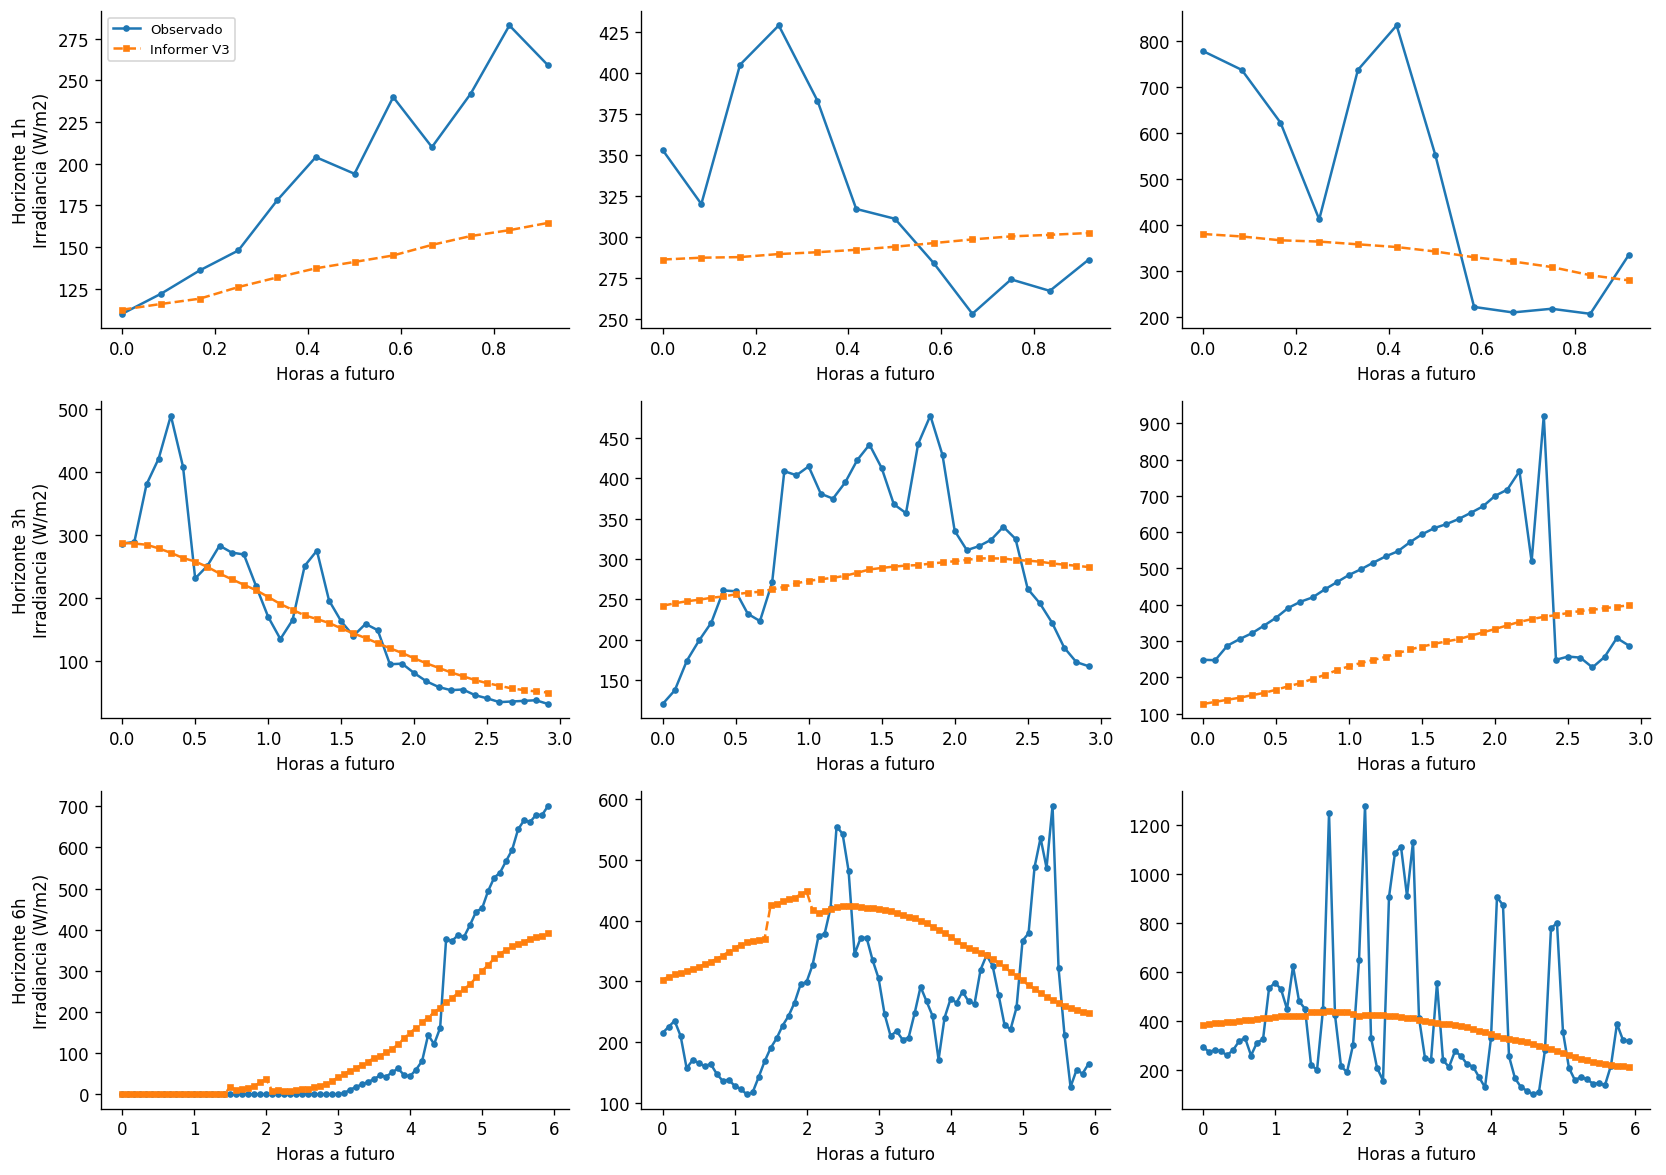

Figura guardada: figuras/prediccion_vs_observacion_repr.png


In [12]:
# 15. PUNTO 2: prediccion frente a observacion con ventanas representativas
# Se eligen ventanas diurnas en los percentiles 25, 50 y 75 de irradiancia media,
# en lugar de la ventana de maxima irradiancia (que exageraba el error).
VAR_EJ = 'V3_completo'   # variante a ilustrar (configurable)

fig, axs = plt.subplots(len(PRED_LENS), 3, figsize=(14, 3.3 * len(PRED_LENS)))
axs = np.atleast_2d(axs)
for r, h in enumerate(PRED_LENS):
    cols = columnas_variante(VAR_EJ)
    data_sub = np.ascontiguousarray(data_norm[:, cols])
    pred_len = PRED_LENS[h]
    ds = InformerDataset(data_sub, marcas_temp, IDX_VAL_END, N_TOTAL,
                         SEQ_LEN, LABEL_LEN, pred_len, idx_objetivo=0)
    loader = DataLoader(Subset(ds, list(range(0, len(ds), 18))), batch_size=128,
                        shuffle=False, num_workers=2, pin_memory=USE_AMP)
    ckpt = os.path.join(RUTA_MODELOS, f'informer_{VAR_EJ}__{h}_{MODO}.pt')
    modelo = build_informer(len(cols), pred_len, HP_BEST)
    modelo.load_state_dict(torch.load(ckpt, map_location=DEVICE)); modelo.eval()
    P, T = [], []
    with torch.no_grad():
        for batch in loader:
            enc, enc_m, dec, dec_m, tgt = _mover(batch)
            with autocast(DEVICE_TYPE, enabled=USE_AMP):
                out = modelo(enc, enc_m, dec, dec_m).squeeze(-1)
            P.append(out.float().cpu().numpy()); T.append(tgt.float().cpu().numpy())
    del modelo; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    P = np.clip(desnormalizar_rs(np.concatenate(P)), 0, None)
    T = desnormalizar_rs(np.concatenate(T))
    media = T.mean(axis=1)
    diurnas = np.where(media > 50)[0]
    ordenadas = diurnas[np.argsort(media[diurnas])]
    sel = [int(ordenadas[min(int(q * len(ordenadas)), len(ordenadas) - 1)]) for q in (0.25, 0.5, 0.75)]
    horas = np.arange(pred_len) * 5 / 60.0
    for cax, idx in zip(axs[r], sel):
        cax.plot(horas, T[idx], 'o-', ms=3, label='Observado')
        cax.plot(horas, P[idx], 's--', ms=3, label='Informer ' + VAR_EJ.split('_')[0])
        cax.set_xlabel('Horas a futuro')
    axs[r, 0].set_ylabel(f'Horizonte {h}\nIrradiancia (W/m2)')
axs[0, 0].legend(fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(RUTA_FIGS, 'prediccion_vs_observacion_repr.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: figuras/prediccion_vs_observacion_repr.png')

         variable  hf_index  autocorr_lag1  frac_sin_cambio  hf_complemento
               RS    0.0517         0.9365           0.6624          0.0635
               KT    0.0544         0.9848           0.5320          0.0152
          WD10M_v    0.0037         0.9995           0.0014          0.0005
ALLSKY_SFC_SW_DWN    0.0066         0.9995           0.4569          0.0005
               PS    0.0042         0.9996           0.0594          0.0004
          WD10M_u    0.0034         0.9996           0.0013          0.0004
CLRSKY_SFC_SW_DWN    0.0096         0.9996           0.4569          0.0004
              SZA    0.0086         0.9996           0.4569          0.0004
             RH2M    0.0052         0.9996           0.0287          0.0004
              T2M    0.0042         0.9997           0.0043          0.0003
      PRECTOTCORR    0.0010         0.9997           0.1743          0.0003
         cos_hora    0.0077         0.9998           0.0000          0.0002
         sin

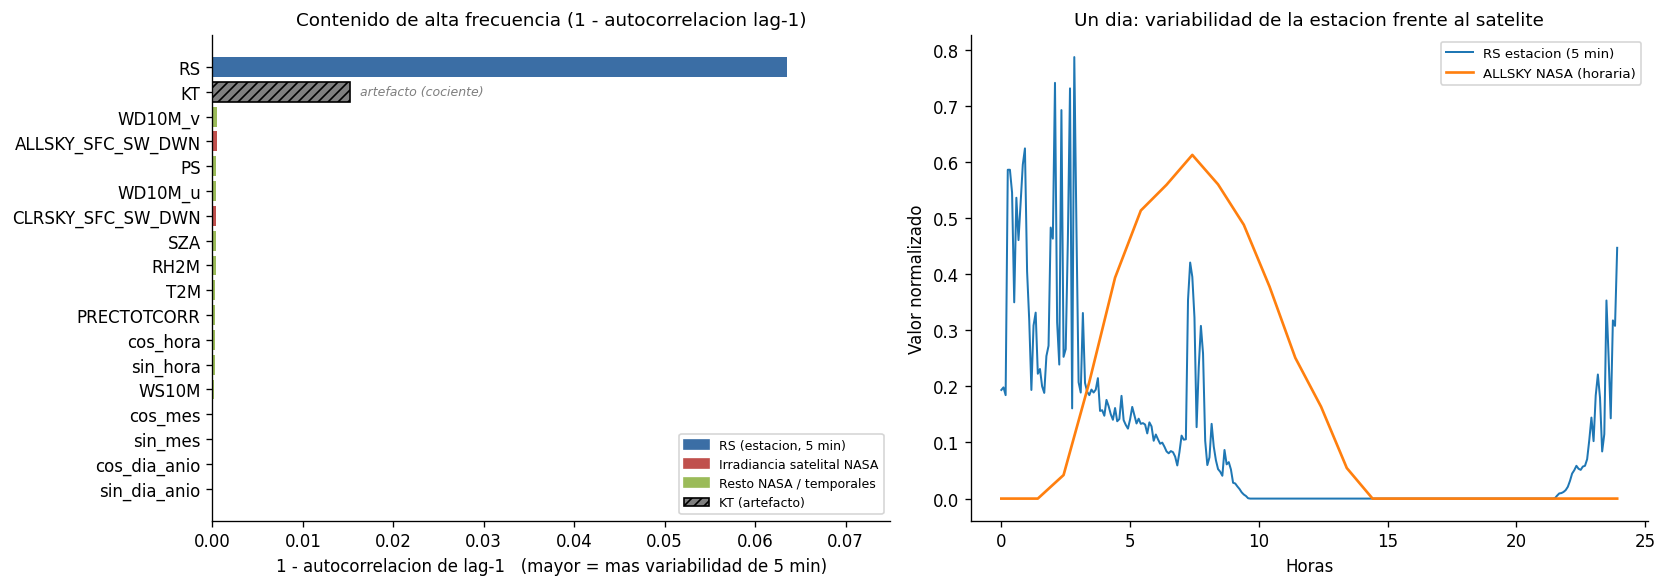

Tabla y figura guardadas: resultados/diagnostico_alta_frecuencia.csv, figuras/diagnostico_alta_frecuencia.png


In [14]:
# 16. PUNTO 3 (revisado): contenido de alta frecuencia medido por autocorrelacion de lag-1
# La autocorrelacion de lag-1 es la metrica mas limpia y defendible: cuanto mas
# cerca de 1, mas suave es la serie entre pasos consecutivos (menos contenido de
# 5 min). Se grafica su complemento (1 - autocorr) para que una barra alta indique
# MAYOR variabilidad de alta frecuencia. El hf_index se conserva en la tabla como
# respaldo, pero NO se usa como metrica principal porque sobrevalora a KT (cociente
# inestable en los bordes del dia).
from matplotlib.patches import Patch

filas_hf = []
for j, v in enumerate(VARS_ENTRADA):
    x = data_norm[:, j].astype(np.float64)
    dif = np.diff(x)
    filas_hf.append(dict(
        variable=v,
        hf_index=float(np.std(dif)),
        autocorr_lag1=float(np.corrcoef(x[:-1], x[1:])[0, 1]),
        frac_sin_cambio=float(np.mean(np.abs(dif) < 1e-6)),
    ))
df_hf = pd.DataFrame(filas_hf)
df_hf['hf_complemento'] = 1.0 - df_hf['autocorr_lag1']
df_hf = df_hf.sort_values('autocorr_lag1').reset_index(drop=True)  # menor autocorr = mas alta frecuencia
df_hf.to_csv(os.path.join(RUTA_RES, 'diagnostico_alta_frecuencia.csv'), index=False)
print(df_hf.round(4).to_string(index=False))

SATELITE_IRR = ['ALLSKY_SFC_SW_DWN', 'CLRSKY_SFC_SW_DWN']
def color_var(v):
    if v == 'RS':         return '#3b6ea5'   # estacion (5 min)
    if v == 'KT':         return '#7f7f7f'   # artefacto del cociente
    if v in SATELITE_IRR: return '#c0504d'   # irradiancia satelital NASA
    return '#9bbb59'                          # resto NASA / temporales

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

orden = df_hf.sort_values('hf_complemento', ascending=True)
colores = [color_var(v) for v in orden['variable']]
barras = axs[0].barh(orden['variable'], orden['hf_complemento'], color=colores)
for b, v in zip(barras, orden['variable']):
    if v == 'KT':
        b.set_hatch('////'); b.set_edgecolor('black')
        axs[0].annotate('artefacto (cociente)',
                        xy=(b.get_width(), b.get_y() + b.get_height() / 2),
                        xytext=(6, 0), textcoords='offset points',
                        va='center', fontsize=7.5, style='italic', color='#7f7f7f')
axs[0].set_xlim(0, float(df_hf['hf_complemento'].max()) * 1.18)
axs[0].set_title('Contenido de alta frecuencia (1 - autocorrelacion lag-1)')
axs[0].set_xlabel('1 - autocorrelacion de lag-1   (mayor = mas variabilidad de 5 min)')
leyenda = [Patch(color='#3b6ea5', label='RS (estacion, 5 min)'),
           Patch(color='#c0504d', label='Irradiancia satelital NASA'),
           Patch(color='#9bbb59', label='Resto NASA / temporales'),
           Patch(facecolor='#7f7f7f', hatch='////', edgecolor='black', label='KT (artefacto)')]
axs[0].legend(handles=leyenda, fontsize=7.5, loc='lower right')

ini = IDX_VAL_END + 5000
seg = slice(ini, ini + 288)            # un dia (288 pasos de 5 min)
horas = np.arange(288) * 5 / 60.0
axs[1].plot(horas, data_norm[seg, VARS_ENTRADA.index('RS')], lw=1.2, label='RS estacion (5 min)')
axs[1].plot(horas, data_norm[seg, VARS_ENTRADA.index('ALLSKY_SFC_SW_DWN')], lw=1.6, label='ALLSKY NASA (horaria)')
axs[1].set_title('Un dia: variabilidad de la estacion frente al satelite')
axs[1].set_xlabel('Horas'); axs[1].set_ylabel('Valor normalizado'); axs[1].legend(fontsize=8)

plt.tight_layout()
fig.savefig(os.path.join(RUTA_FIGS, 'diagnostico_alta_frecuencia.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Tabla y figura guardadas: resultados/diagnostico_alta_frecuencia.csv, figuras/diagnostico_alta_frecuencia.png')

## Resumen de salidas

- `resultados/metricas_variantes.csv` — tabla ampliada con error medio (ME) global y diurno, ademas de MAE, RMSE, R2, sMAPE y *skill* frente a persistencia.
- `figuras/diagnostico_residuales_*.png` — ACF y Ljung-Box (autocorrelacion residual), sesgo por nivel de irradiancia y por hora, y residual frente a observado.
- `figuras/prediccion_vs_observacion_repr.png` — prediccion frente a observacion en ventanas representativas.
- `resultados/diagnostico_alta_frecuencia.csv` y `figuras/diagnostico_alta_frecuencia.png` — evidencia de que la irradiancia satelital horaria de NASA carece del contenido de alta frecuencia de la RS de 5 min.

**Lectura sugerida:** el ME negativo y su concentracion en niveles altos de irradiancia documentan que el modelo subestima los picos; la autocorrelacion residual a retardos cortos confirma que queda dinamica de corto plazo sin capturar; y el diagnostico de alta frecuencia sustenta, de forma cuantitativa, por que agregar la irradiancia satelital horaria no mejora la prediccion a 5 minutos.